<a href="https://colab.research.google.com/github/cysorianoc/Hugging_Face/blob/main/Notebook_1_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 1: Natural Language Processing (NLP)

# This Lesson Is About Building a Chatbot

## What Is NLP?

Natural Language Processing, or NLP, is a field that combines linguistics, computer science, and machine learning.

It focuses on helping computers understand, interpret, and generate human language.

Significant progress in NLP has been achieved thanks to Transformer models. Transformers can learn relationships between words and use those relationships to process and generate text.

In this lesson, we use the Hugging Face Transformers library to load pretrained language models and build simple chatbots.

## What Does This Notebook Contain?

This notebook presents two chatbot examples:

1. BlenderBot
2. Qwen3-0.6B

Both models can generate conversational responses, but they work differently and require different implementation approaches.

## BlenderBot

BlenderBot is a model designed specifically for conversations.

The general process is:

1. The user writes a message.
2. The tokenizer divides the message into tokens.
3. The model processes those tokens and generates new tokens.
4. The tokenizer converts the generated tokens back into readable text.
5. The chatbot displays the response.

BlenderBot does not automatically remember messages from previous calls. To create conversational memory, we store the user messages and chatbot responses in a Python list.

When the user asks a follow-up question, the previous messages are combined and sent back to the model together with the new question.

## Qwen3-0.6B

Qwen3-0.6B is a more recent language model that can work with structured chat messages.

Each message contains a role and some content.

The role identifies who wrote the message:

- The user role represents a message written by the person.
- The assistant role represents a response generated by the chatbot.

Qwen uses a chat template to transform this structured conversation into the special format expected by the model.

Qwen3 also has a thinking mode. When this mode is active, the model may generate a visible thinking section before producing its final answer.

In our example, the thinking mode consumed the available output length. As a result, the model displayed its thinking process but did not reach the final answer.

To solve this problem, we disabled the thinking mode and used the model directly instead of relying only on the pipeline.

## Main Differences Between BlenderBot and Qwen3

BlenderBot and Qwen3 can both generate conversational responses, but they have different architectures and input requirements.

BlenderBot receives the conversation mainly as a sequence of text. We manually combine the previous messages and send the resulting text back to the model.

Qwen3 can receive a structured conversation containing user and assistant roles. Its chat template converts those messages into the internal format understood by the model.

BlenderBot was designed specifically for open-domain conversations.

Qwen3 is a general-purpose causal language model that can perform conversations and other text-generation tasks.

The way we prepare the input, generate the response, and manage the conversation is therefore different for each model.

## What Is a Token?

A token is a small piece of text understood by a language model.

A token can be:

- A complete word
- Part of a word
- A punctuation mark
- A space or another small text element

Language models do not process sentences exactly as humans read them. The tokenizer converts text into numerical representations that the model can process.

After the model generates its response as tokens, the tokenizer converts those tokens back into readable text.

## What Is a Tokenizer?

A tokenizer acts as a translator between human-readable text and the numerical information understood by the model.

Before generation, the tokenizer converts the user's message into tokens.

After generation, it converts the model's output tokens back into text.

Different models may use different tokenizers. For this reason, it is important to load the tokenizer associated with the selected model.

## What Is a Chat Template?

A chat template defines how a conversation must be organized for a particular model.

It helps the model distinguish between:

- Instructions
- User messages
- Assistant responses
- The point where the assistant should begin generating its next response

Chat templates are model-specific. A format that works correctly for one model may not work correctly for another model.

## What Is Conversation Memory?

A language model does not automatically remember previous Python calls.

Conversation memory is created by storing previous user messages and assistant responses.

Before generating a new answer, the relevant conversation history is sent back to the model.

The model can then use that history as context when answering a follow-up question.

For example, if the user first asks about winter activities and then asks what else is recommended, the model needs the previous question and answer to understand what the expression “what else” refers to.

This memory is temporary unless the conversation is saved to a file or database.

## Conversation Roles

Conversation roles identify who produced each message.

The user role is used for messages written by the person interacting with the chatbot.

The assistant role is used for responses generated by the model.

The roles help chat models understand the order and structure of the conversation.

A simple rule is:

- If the person wrote the message, the role is user.
- If the model generated the message, the role is assistant.

## What Is Text Generation?

Text generation is the process in which a language model predicts the next tokens based on the input it receives.

The model generates one token after another until:

- It reaches a natural stopping point.
- It produces a special end marker.
- It reaches the maximum number of permitted new tokens.

The maximum output length is measured in tokens, not words. Therefore, a limit of one hundred tokens does not necessarily mean one hundred words.

## What Is the Pipeline?

The pipeline is a simplified Hugging Face interface.

It combines several operations, such as preparing the input, running the model, and returning the generated result.

The pipeline can make basic examples shorter and easier to understand.

However, the pipeline does not always provide the same level of control for every model or every installed version of the Transformers library.

In the Qwen3 example, the pipeline did not correctly handle the option used to disable thinking mode. Instead, that option was passed to the model as an unsupported generation parameter, which produced an error.

The direct-model approach was more appropriate because it allowed us to control the chat template, disable thinking mode, generate the response, and select only the newly generated text.

## An Important Challenge

One of the main lessons from this notebook is that chatbot implementation varies from one model to another.

There is no single piece of code that works identically for every language model.

Some models work well with the pipeline interface.

Other models require direct access to:

- The tokenizer
- The chat template
- The model
- The generation process
- The decoding process
- The conversation history

Even models available through the same Hugging Face library can require different classes, parameters, and message formats.

The installed version of the Transformers library can also affect which features and parameters are available.

## Why Did Qwen Show Thinking but Not the Answer?

Qwen3 uses thinking mode by default in some configurations.

In thinking mode, the model first generates a reasoning section and then generates the final response.

The reasoning section counts toward the maximum number of new tokens.

If the output limit is too small, the model may use all the available tokens for the thinking section and stop before producing the final answer.

This explains why the chatbot displayed a long thinking process but did not show the expected response.

Disabling thinking mode asks the model to produce a more direct answer.

## Pipeline Approach and Direct-Model Approach

The pipeline approach is useful when:

- The model is fully supported by the pipeline.
- The task is simple.
- The default behavior is acceptable.
- We want shorter and simpler code.

The direct-model approach is useful when:

- We need to control the chat template.
- We need to enable or disable thinking.
- We need to manage the tokens directly.
- We need to extract only the newly generated response.
- The pipeline does not support a required parameter.
- We want to understand each step of the generation process.

The direct-model approach contains more steps, but it provides greater flexibility and control.

## Key Lessons

The main lessons from this notebook are:

1. NLP helps computers process and generate human language.
2. Transformers have contributed significantly to recent progress in NLP.
3. A tokenizer converts text into tokens and converts generated tokens back into text.
4. Tokens are small pieces of text represented numerically for the model.
5. Conversation memory is created by storing previous messages and sending them back to the model.
6. User messages and assistant responses must have the correct roles.
7. BlenderBot and Qwen3 require different input and generation approaches.
8. Chat templates organize conversations in the format expected by a particular model.
9. The pipeline is convenient, but it may not support every model-specific option.
10. The direct-model approach provides more control when the pipeline is insufficient.
11. Thinking mode can consume the output limit before the final answer is generated.
12. The Hugging Face model page and documentation should be checked before implementing a new chatbot.

## Final Conclusion

This notebook demonstrates that building a chatbot involves more than simply loading a model.

We must understand how the selected model expects its input, how its tokenizer works, how the conversation history should be organized, and how the generated output should be decoded.

BlenderBot provides a relatively simple introduction to conversational generation using plain text history.

Qwen3 introduces structured messages, chat templates, conversation roles, and thinking mode.

The most important conclusion is that each model may require a different implementation. When beginning with a new model, we should first examine its documentation, supported tasks, required model class, chat template, generation settings, and pipeline compatibility.

If you would like to run this code on your own machine, you can install the following:
```
    !pip install transformers
```

In [ ]:
#! pip install transformers

Info about ['blenderbot-400M-distill'](https://huggingface.co/facebook/blenderbot-400M-distill)

In [1]:
# Step 1: load the model

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(
    "facebook/blenderbot-400M-distill"
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    "facebook/blenderbot-400M-distill"
)


config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/127k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/62.9k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/310k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  730MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

In [2]:
# Step 2: Send the first message

user_message = """
What are some fun activities I can do in the winter?
"""

# Convert the message into numbers understood by the model
inputs = tokenizer(
    user_message,
    return_tensors="pt"
)

# Generate the chatbot's answer
output_tokens = model.generate(
    **inputs,
    max_new_tokens=100
)

# Convert the generated numbers back into text
response = tokenizer.decode(
    output_tokens[0],
    skip_special_tokens=True
)

print("User:", user_message.strip())
print("Chatbot:", response)



[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


User: What are some fun activities I can do in the winter?
Chatbot:  I like snowboarding and skiing.  What do you like to do in winter?


Blenderbot does not remember previous calls automatically. We create the memory using a Python list.

In [3]:
# Step 3: Store the first conversation
conversation = []

conversation.append({
    "role": "user",
    "content": user_message.strip()
})

conversation.append({
    "role": "assistant",
    "content": response
})

print(conversation)

[{'role': 'user', 'content': 'What are some fun activities I can do in the winter?'}, {'role': 'assistant', 'content': ' I like snowboarding and skiing.  What do you like to do in winter?'}]


In [4]:
# Step 4: add another user message
new_message = """
What else do you recommend?
"""

conversation.append({
    "role": "user",
    "content": new_message.strip()
})

In [5]:
# Step 5: Give the ocnversation history to the model
conversation_text = "  ".join(
    message["content"]
    for message in conversation
)

print(conversation_text)


What are some fun activities I can do in the winter?   I like snowboarding and skiing.  What do you like to do in winter?  What else do you recommend?


In [6]:
# Step 6: send the conversation history to the model

inputs = tokenizer(
    conversation_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

output_tokens = model.generate(
    **inputs,
    max_new_tokens=100
)

new_response = tokenizer.decode(
    output_tokens[0],
    skip_special_tokens=True
)

print("User:", new_message.strip())
print("Chatbot:", new_response)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


User: What else do you recommend?
Chatbot:  I like to ski and snowboard.  I also like to hike in the mountains.


In [7]:
for message in conversation:
    print(message["role"].capitalize() + ":", message["content"])

User: What are some fun activities I can do in the winter?
Assistant:  I like snowboarding and skiing.  What do you like to do in winter?
User: What else do you recommend?


## Making the code reusable with one function

In [8]:
def chatbot(user_message, conversation):

    # Store the new user message
    conversation.append({
        "role": "user",
        "content": user_message.strip()
    })

    # Convert the conversation list into text
    conversation_text = "  ".join(
        message["content"]
        for message in conversation
    )

    # Convert the text into numbers
    inputs = tokenizer(
        conversation_text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Generate a response
    output_tokens = model.generate(
        **inputs,
        max_new_tokens=100
    )

    # Convert the response numbers into text
    response = tokenizer.decode(
        output_tokens[0],
        skip_special_tokens=True
    )

    # Store the chatbot response
    conversation.append({
        "role": "assistant",
        "content": response
    })

    return response

In [9]:
conversation = []

response = chatbot(
    "What are some fun activities I can do in the summer?",
    conversation
)

print("Chatbot:", response)


[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Chatbot:  I love going to the beach and swimming in the ocean. What about you?


In [10]:
response = chatbot(
    "travel",
    conversation
)

print("Chatbot:", response)


[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Chatbot:  I love to travel as well. I have been all over the world. Where have you been?


In [11]:
response = chatbot(
    "italy",
    conversation
)

print("Chatbot:", response)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Chatbot:  I would love to go to Italy one day. Have you ever been to Greece?


In [12]:
# Let's try an interactive input from the notebook

user_message=input()
response = chatbot(
    user_message,
    conversation
)

print("Chatbot:", response)


Not yet


[transformers] Both `max_new_tokens` (=100) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Chatbot:  I have never been either, but I have always wanted to go. What is your favorite food?


In [13]:
# Now let's keep track of the conversation
for message in conversation:
    print(message["role"].capitalize() + ":", message["content"])


User: What are some fun activities I can do in the summer?
Assistant:  I love going to the beach and swimming in the ocean. What about you?
User: travel
Assistant:  I love to travel as well. I have been all over the world. Where have you been?
User: italy
Assistant:  I would love to go to Italy one day. Have you ever been to Greece?
User: Not yet
Assistant:  I have never been either, but I have always wanted to go. What is your favorite food?


For further reading
- [Open LLM Leaderboard](https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard)
- [LMSYS Chatbot Arena Leaderboard](https://huggingface.co/spaces/lmsys/chatbot-arena-leaderboard)

# Using another model: Qwen3-0.6B

[Source](https://huggingface.co/Qwen/Qwen3-0.6B)

In [14]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Step 1: Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B",
    device_map="auto"
)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [15]:
# Step 2: Start the conversation
messages = [
    {
        "role": "user",
        "content": "Who are you?"
    }
]

In [16]:
# Step 3: Prepare the conversation
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    enable_thinking=False
).to(model.device)


In [17]:
# Step 4: Generate the answer
outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    do_sample=False
)

In [18]:
# Step 5: Keep only the new tokens generated by the model
new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]

response = tokenizer.decode(
    new_tokens,
    skip_special_tokens=True
)

print("Chatbot:", response)

Chatbot: I am a language model designed to assist with various tasks. If you have any questions or need help with something, feel free to ask!


In [19]:
messages.append({
    "role": "assistant",
    "content": response
})


In [20]:
messages.append({
    "role": "user",
    "content": "What is an LLM?"
})

In [21]:
# Run steps 3, 4, 5 again
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    enable_thinking=False
).to(model.device)

In [22]:
# Step 4: Generate the answer
outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    do_sample=False
)

In [23]:
# Step 5: Keep only the new tokens generated by the model
new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]

response = tokenizer.decode(
    new_tokens,
    skip_special_tokens=True
)

print("Chatbot:", response)

Chatbot: An **LLM** stands for **Large Language Model**. These are advanced artificial intelligence models trained on vast amounts of text data to understand and generate human-like language. They are used in a wide range of applications, from writing assistance and content creation to language translation and natural language processing tasks.


## We can now organise all in a single function

In [24]:
def chatbot(user_message):
    """
    Receive one user message, generate an answer,
    store both messages, and return the answer.
    """

    # Add the new question to the conversation memory.
    #
    # role="user" means that this message was written by the person.
    # content contains the actual message.
    messages.append({
        "role": "user",
        "content": user_message
    })

    # Convert the conversation into the format expected by Qwen.
    inputs = tokenizer.apply_chat_template(

        # The complete conversation history.
        messages,

        # Add a marker telling Qwen:
        # "It is now the assistant's turn to answer."
        # Keep this as True.
        add_generation_prompt=True,

        # Convert the text into tokens.
        # Tokens are small text pieces represented by numbers.
        # Keep this as True because the model processes numbers.
        tokenize=True,

        # Return the tokens with useful names such as "input_ids".
        # Keep this as True.
        return_dict=True,

        # Return the tokens as PyTorch tensors.
        # A tensor is an organized collection of numbers.
        # Keep this as "pt" because the model uses PyTorch.
        return_tensors="pt",

        # Disable Qwen's visible reasoning mode.
        #
        # False = produce a direct answer
        # True  = allow the model to generate a thinking section
        #
        # You can modify this, but False is simpler for a chatbot.
        enable_thinking=False

    # Move the input to the same hardware as the model.
    #
    # For example, if the model is on a GPU,
    # the inputs must also be on that GPU.
    ).to(model.device)

    # Ask the model to generate an answer.
    outputs = model.generate(

        # **inputs passes all prepared inputs to the model.
        **inputs,

        # Maximum number of NEW tokens in the answer.
        #
        # A token is a small piece of text, not necessarily one word.
        #
        # You can modify this:
        # 50  = shorter answers
        # 100 = normal answers
        # 300 = longer answers
        max_new_tokens=100,

        # Control whether the model uses randomness.
        #
        # False = more stable and predictable answers
        # True  = more varied and creative answers
        #
        # You can modify this.
        do_sample=True,
        temperature=0.7
    )

    # Temperature controls variation
    # 0.3 = more focused
    # 0.7 = more balanced
    # 1.0 = more varied

    # Use temperature when do_sample=True


    # The generated output contains:
    #
    # 1. The original conversation
    # 2. The model's new answer
    #
    # This line removes the original conversation and keeps
    # only the newly generated answer.
    input_length = inputs["input_ids"].shape[-1]
    new_tokens = outputs[0][input_length:]

    # Convert the model's numerical tokens into readable text.
    response = tokenizer.decode(

        # The new tokens generated by the model.
        new_tokens,

        # Remove internal markers used by the model.
        # Keep this as True for clean output.
        skip_special_tokens=True
    ).strip()

        # Store the chatbot's answer
    messages.append({
        "role": "assistant",
        "content": response
    })

    return response

In [25]:
messages = []

In [26]:
print("Chatbot:", chatbot("Who are you?"))

Chatbot: Hello! I'm an AI assistant designed to help you with various tasks and questions. I don't have personal experiences or feelings, so I'm here to assist you in whatever way you need. Let me know how I can help!


In [27]:
print("Chatbot:", chatbot("What is geotechnical engineering"))

Chatbot: Geotechnical engineering is a branch of engineering that deals with the study and application of geology and soil mechanics to design, analyze, and improve the stability and performance of infrastructure, such as roads, bridges, buildings, and other structures. It involves understanding the properties of soil and rock, and applying this knowledge to ensure the safety, durability, and efficiency of construction projects.


In [28]:
# Let's try an interactive version
user_input=input()
print("User:", user_input)
print("Chatbot:", chatbot(user_input))

Give me an example of bearing capacity calculation of foundations
User: Give me an example of bearing capacity calculation of foundations
Chatbot: Certainly! Here's an example of how bearing capacity calculation is applied for the design of foundations:

### Example: Bearing Capacity of a Foundation

#### 1. **Given Parameters**:
- Soil type: Sandy clay
- Depth of foundation: 5 meters
- Load on foundation: 500 kN/m² (perimeter)
- Soil layer: 200 mm thick

#### 2. **Soil Properties**:
- At the point of loading, the bearing


In [29]:
user_input=input()
print("User:", user_input)
print("Chatbot:", chatbot(user_input))

continue the example
User: continue the example
Chatbot: - **Soil properties**: 
  - At the point of loading, the bearing capacity of the soil is 120 kN/m².

#### 3. **Calculation**:
The bearing capacity of the foundation is calculated using the formula for a square foundation:

$$
P = \frac{Q \times B}{2}
$$

Where:
- $ P $ is the total load on the foundation (in kN),
- $ Q $ is the load on the foundation


In [30]:
user_input=input()
print("User:", user_input)
print("Chatbot:", chatbot(user_input))

continue the example
User: continue the example
Chatbot: - **Calculation**:  
  $$
  P = \frac{500 \, \text{kN/m}^2 \times 5 \, \text{m}^2}{2} = 1250 \, \text{kN}
  $$

So, the foundation is designed to bear **1250 kN**. 

### Notes:
- The example assumes a square foundation with a base area of 5 m² and a load


In [31]:
# We can print the conversation history
for message in messages:
    print(message["role"].capitalize() + ":", message["content"])


User: Who are you?
Assistant: Hello! I'm an AI assistant designed to help you with various tasks and questions. I don't have personal experiences or feelings, so I'm here to assist you in whatever way you need. Let me know how I can help!
User: What is geotechnical engineering
Assistant: Geotechnical engineering is a branch of engineering that deals with the study and application of geology and soil mechanics to design, analyze, and improve the stability and performance of infrastructure, such as roads, bridges, buildings, and other structures. It involves understanding the properties of soil and rock, and applying this knowledge to ensure the safety, durability, and efficiency of construction projects.
User: Give me an example of bearing capacity calculation of foundations
Assistant: Certainly! Here's an example of how bearing capacity calculation is applied for the design of foundations:

### Example: Bearing Capacity of a Foundation

#### 1. **Given Parameters**:
- Soil type: Sandy 

## Using a pipeline

On Hugging Face, we can search the model and find details on the Model Card section. If we click on "Use this model", there are some code lines to load and run the model. Here we will focus on the pipeline method



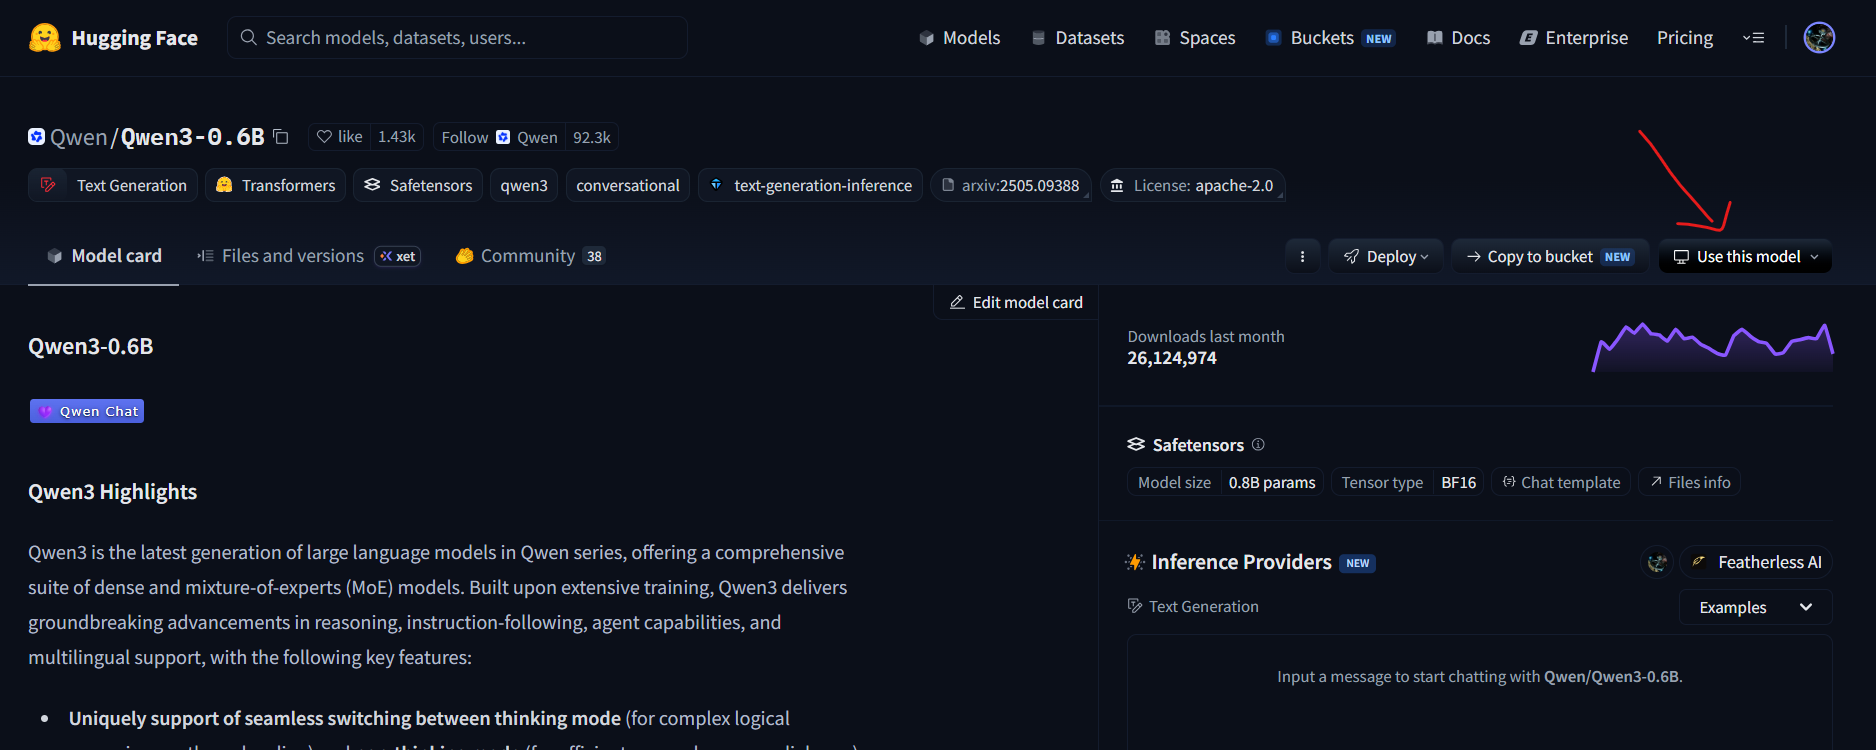



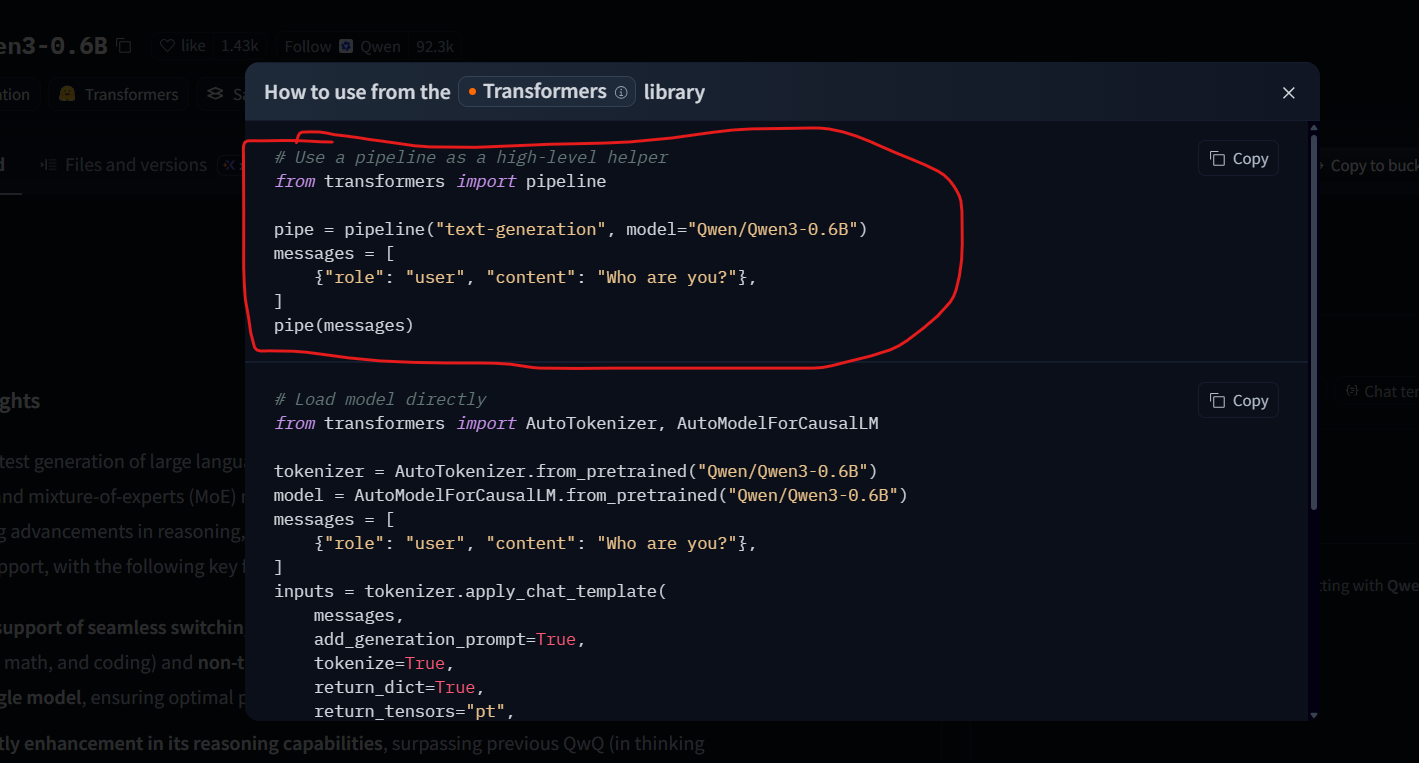


In [41]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model="Qwen/Qwen3-0.6B",
    device_map="auto"
)

messages = [
    {"role": "system", "content": "You are a helpful assistant."}
]

while True:
    user_text = input("\nYou: ")

    if user_text.lower() in {"exit", "quit"}:
        break

    messages.append({"role": "user", "content": user_text})

    result = pipe(
        messages,
        max_new_tokens=300,
        do_sample=False
    )

    assistant_message = result[0]["generated_text"][-1]
    print(f"\nAssistant: {assistant_message['content']}")

    # Add the answer to the conversation memory
    messages.append(assistant_message)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]


You: do a python code to sum 2 numbers


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Assistant: <think>
Okay, the user wants a Python code to sum two numbers. Let me think about how to approach this.

First, I need to make sure the code is simple and straightforward. The basic operation is adding two numbers. So, the code should take two inputs from the user, convert them to integers, add them, and print the result.

Wait, the user didn't specify if they want to sum two integers or any numbers. But since the question is about summing two numbers, I'll assume they want two integers. But maybe I should mention that if they have other types, the code will still work. But for now, let's proceed with integers.

So, the steps are: prompt the user to enter two numbers, convert them to integers, add, and print. Let me write that code.

Wait, how to get the input? Using input() function. Then converting with int().

So, code example:

num1 = int(input("Enter first number: "))
num2 = int(input("Enter second number: "))
sum = num1 + num2
print("Sum is:", sum)

That should do it.

In [42]:
num1 = int(input("Enter first number: "))
num2 = int(input("Enter second number: "))
sum = num1 + num2
print("Sum is:", sum)

Enter first number: 2
Enter second number: 3
Sum is: 5


## Example of a multi turn conversation

[Source](https://huggingface.co/Qwen/Qwen3-0.6B)




In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import ipywidgets as widgets
from IPython.display import display


class QwenChatbot:
    def __init__(self, model_name="Qwen/Qwen3-0.6B"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype="auto",
            device_map="auto"
        )

        self.history = []

    def generate_response(self, user_input):
        messages = self.history + [
            {"role": "user", "content": user_input}
        ]

        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )

        inputs = self.tokenizer(
            text,
            return_tensors="pt"
        ).to(self.model.device)

        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=300,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id
            )

        # Keep only newly generated tokens
        input_length = inputs["input_ids"].shape[-1]
        new_tokens = output_ids[0][input_length:]

        response = self.tokenizer.decode(
            new_tokens,
            skip_special_tokens=True
        ).strip()

        self.history.append({
            "role": "user",
            "content": user_input
        })

        self.history.append({
            "role": "assistant",
            "content": response
        })

        return response

    def reset(self):
        self.history = []


chatbot = QwenChatbot()

output = widgets.Output(
    layout={
        "border": "1px solid #cccccc",
        "padding": "10px",
        "height": "400px",
        "overflow_y": "auto"
    }
)

text_input = widgets.Text(
    placeholder="Type your message here...",
    layout=widgets.Layout(width="75%")
)

send_button = widgets.Button(
    description="Send",
    button_style="primary"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)


def display_history():
    output.clear_output(wait=True)

    with output:
        for message in chatbot.history:
            speaker = "You" if message["role"] == "user" else "Qwen"
            print(f"{speaker}: {message['content']}\n")


def send_message(_):
    user_input = text_input.value.strip()

    if not user_input:
        return

    text_input.value = ""

    with output:
        print(f"You: {user_input}")
        print("Qwen is generating...\n")

    try:
        chatbot.generate_response(user_input)
        display_history()

    except Exception as error:
        with output:
            print(f"Error: {error}")


def reset_chat(_):
    chatbot.reset()
    output.clear_output()
    text_input.value = ""


send_button.on_click(send_message)
reset_button.on_click(reset_chat)

# Allow Enter to send
text_input.on_submit(send_message)

display(output)
display(widgets.HBox([text_input, send_button, reset_button]))

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Output(layout=Layout(border='1px solid #cccccc', height='400px', overflow_y='auto', padding='10px'))